In [55]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import minimize


In [56]:
PROJECT_ROOT = Path("/Users/bgifford/Documents/HOA/Ridge Park Reserve Study")
VARIANT_NAME = "2026_brendan_plan"
BASE_DIR = PROJECT_ROOT / VARIANT_NAME
SOURCE_DATA = BASE_DIR / "source_data"
WORKING_CSV = BASE_DIR / "working_csv"

COMPONENT_FILE = SOURCE_DATA / "component_list_v2.csv"
ASSUMPTIONS_FILE = SOURCE_DATA / "assumptions.csv"
ASSESSMENT_FILE = SOURCE_DATA / "assessment_contributions.csv"

In [57]:
from reserve_study_v3_3 import (
    DAY_OF_MONTH,
    normalize_to_month,
    add_months,
    months_between,
    load_assumptions,
    load_components,
    load_assessment_contributions,
    build_component_list_detail,
    build_expenditures_by_year_detail,
    build_expenditures_by_year_summary,
    build_expenditures_matrix,
    build_reserve_projection,
    build_funded_balance,
)

In [58]:
assumptions = load_assumptions(ASSUMPTIONS_FILE)
START_YEAR = pd.Timestamp(assumptions["analysis_date"]).year

components_raw = load_components(COMPONENT_FILE)
assessment_contributions = load_assessment_contributions(ASSESSMENT_FILE)
component_list_detail = build_component_list_detail(
    components_raw,
    assumptions
)

In [59]:
start_contribution = float(
    assessment_contributions.loc[
        assessment_contributions["year"].astype(int) == int(START_YEAR),
        "contribution",
    ].iloc[0]
)

component_list_detail = pd.read_csv(
    WORKING_CSV / "component_list_detail.csv",
    parse_dates=["service_date", "replacement_date"]
)

expenditures_by_year_detail = pd.read_csv(
    WORKING_CSV / "expenditures_by_year_detail.csv",
    parse_dates=["replacement_date"]
)

expenditures_by_year_summary = pd.read_csv(
    WORKING_CSV / "expenditures_by_year_summary.csv"
)

#assessment_contributions = pd.read_csv(
#    SOURCE_DATA / "assessment_contributions.csv"
#)

assumptions_df = pd.read_csv(
    SOURCE_DATA / "assumptions.csv"
)

reserve_projection = pd.read_csv(
    WORKING_CSV / "reserve_projection.csv"
)

expenditures_matrix = build_expenditures_matrix(
    expenditures_by_year_detail,
    projection_years=30
)

fb_end = build_funded_balance(
    component_list_detail,
    assumptions,
    projection_years=PROJECTION_YEARS,
    method="current_cost_straight_line",
    funded_date="end",
    respect_one_time=True,
    inflate_result=True,
)

In [ ]:
reserve_projection = build_reserve_projection(
    expenditures_by_year_detail=expenditures_by_year_detail,
    assumptions=assumptions,
    assessment_contributions=assessment_contributions,
    start_year=START_YEAR,
    projection_years=30,
)

reserve_projection

    year  contribution  special_assessment
0   2026        250000                   0
1   2027        300000                   0
2   2028        350000                   0
3   2029        400000                   0
4   2030        450000                   0
5   2031        500000                   0
6   2032        520000                   0
7   2033        540000                   0
8   2034        560000                   0
9   2035        580000                   0
10  2036        600000                   0
11  2037        610000                   0
12  2038        620000                   0
13  2039        630000                   0
14  2040        640000                   0
15  2041        650000                   0
16  2042        660000                   0
17  2043        661139                   0
18  2044        680973                   0
19  2045        701402                   0
20  2046        722444                   0
21  2047        744118                   0
22  2048   

,year,begin_balance,contribution,special_assessment,expenditures,interest,end_balance
0,2026,800000.00,250000.0,0.0,313093.32,20367.17,757273.85
1,2027,757273.85,300000.0,0.0,233109.89,20805.62,844969.58
2,2028,844969.58,350000.0,0.0,468771.86,21240.53,747438.24
3,2029,747438.24,400000.0,0.0,332699.03,20879.74,835618.95
4,2030,835618.95,450000.0,0.0,627675.52,20706.47,678649.90
5,2031,678649.90,500000.0,0.0,460389.79,19169.08,737429.19
6,2032,737429.19,520000.0,0.0,351127.95,22071.33,928372.57
7,2033,928372.57,540000.0,0.0,113410.15,29659.47,1384621.90
8,2034,1384621.90,560000.0,0.0,354705.65,38946.24,1628862.48
9,2035,1628862.48,580000.0,0.0,628147.58,42535.37,1623250.28


### Reserve Optimization Framework

In [61]:
# FRAMEWORK
# Reserve study optimization engine and helpers

# HELPERS

def make_years(start_year, projection_years):
    return np.arange(int(start_year), int(start_year) + int(projection_years), dtype=int)

def make_min_balance_array(years, min_balance):
    years = np.asarray(years, dtype=int)

    if np.isscalar(min_balance):
        return np.full(len(years), float(min_balance), dtype=float)

    if isinstance(min_balance, dict):
        return np.array([float(min_balance.get(int(y), 0.0)) for y in years], dtype=float)

    arr = np.asarray(min_balance, dtype=float)
    if len(arr) != len(years):
        raise ValueError("min_balance array must match number of projection years")
    return arr

def get_existing_contributions(years, assessment_contributions):
    base = assessment_contributions.copy()
    base["year"] = base["year"].astype(int)

    merged = pd.DataFrame({"year": years}).merge(
        base[["year", "contribution"]],
        on="year",
        how="left",
    ).fillna(0.0)

    return merged["contribution"].to_numpy(dtype=float)

def get_existing_special_assessments(years, assessment_contributions):
    base = assessment_contributions.copy()
    base["year"] = base["year"].astype(int)

    merged = pd.DataFrame({"year": years}).merge(
        base[["year", "special_assessment"]],
        on="year",
        how="left",
    ).fillna(0.0)

    return merged["special_assessment"].to_numpy(dtype=float)

# Special Assessment

def resolve_special_assessments(
    years,
    assessment_contributions=None,
    mode="zero",              # "zero", "existing", "fixed_vector", "fixed_dict", "function"
    special_vector=None,
    special_dict=None,
    special_func=None,
):
    years = np.asarray(years, dtype=int)

    if mode == "zero":
        return np.zeros(len(years), dtype=float)

    if mode == "existing":
        if assessment_contributions is None:
            raise ValueError("assessment_contributions is required for mode='existing'")
        return get_existing_special_assessments(years, assessment_contributions)

    if mode == "fixed_vector":
        if special_vector is None:
            raise ValueError("special_vector is required for mode='fixed_vector'")
        vec = np.asarray(special_vector, dtype=float)
        if len(vec) != len(years):
            raise ValueError("special_vector length must match number of years")
        return vec

    if mode == "fixed_dict":
        if special_dict is None:
            raise ValueError("special_dict is required for mode='fixed_dict'")
        return np.array([float(special_dict.get(int(y), 0.0)) for y in years], dtype=float)

    if mode == "function":
        if special_func is None:
            raise ValueError("special_func is required for mode='function'")
        vec = np.asarray(special_func(years), dtype=float)
        if len(vec) != len(years):
            raise ValueError("special_func(years) must return one value per year")
        return vec

    raise ValueError("Unsupported special assessment mode")


# Build Annual Assessment Schedule

def build_assessment_schedule(years, contribution_vector, special_vector=None):
    years = np.asarray(years, dtype=int)
    contribution_vector = np.asarray(contribution_vector, dtype=float)

    if special_vector is None:
        special_vector = np.zeros(len(years), dtype=float)
    else:
        special_vector = np.asarray(special_vector, dtype=float)

    if len(contribution_vector) != len(years):
        raise ValueError("contribution_vector length must match years")

    if len(special_vector) != len(years):
        raise ValueError("special_vector length must match years")

    return pd.DataFrame({
        "year": years,
        "contribution": contribution_vector,
        "special_assessment": special_vector,
    })


def run_projection_from_contributions(
    years,
    contribution_vector,
    expenditures_by_year_detail,
    assumptions,
    special_vector=None,
    starting_balance=None,
):
    assessment_df = build_assessment_schedule(
        years=years,
        contribution_vector=contribution_vector,
        special_vector=special_vector,
    )

    projection = build_reserve_projection(
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        assessment_contributions=assessment_df,
        start_year=int(years[0]),
        projection_years=len(years),
        starting_balance=starting_balance,
    )

    return assessment_df, projection


# Contribution Post Processing

def transform_contributions(
    contribution_vector,
    round_to=None,
    floor_at_zero=True,
):
    vec = np.asarray(contribution_vector, dtype=float).copy()

    if floor_at_zero:
        vec = np.maximum(vec, 0.0)

    if round_to is not None and round_to > 0:
        vec = np.round(vec / round_to) * round_to

    return vec

# General Optimization Routine

def optimize_reserve_schedule(
    contribution_fn,
    objective_fn,
    initial_params,
    bounds,
    expenditures_by_year_detail,
    assumptions,
    assessment_contributions=None,
    start_year=None,
    projection_years=30,
    min_balance=0.0,
    special_mode="zero",
    special_vector=None,
    special_dict=None,
    special_func=None,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
    method="SLSQP",
    options=None,
    plot_progress=True,
    plot_every=1,
):
    if minimize is None:
        raise ImportError("scipy is required for optimize_reserve_schedule()")

    import matplotlib.pyplot as plt
    from IPython.display import clear_output, display
    if start_year is None:
        start_year = pd.Timestamp(assumptions["analysis_date"]).year
        
    years = make_years(start_year, projection_years)
    min_balance_array = make_min_balance_array(years, min_balance)

    resolved_special = resolve_special_assessments(
        years=years,
        assessment_contributions=assessment_contributions,
        mode=special_mode,
        special_vector=special_vector,
        special_dict=special_dict,
        special_func=special_func,
    )

    if options is None:
        options = {"maxiter": 2000, "ftol": 1e-9, "disp": False}

    def build_contrib_from_params(params):
        contrib = np.asarray(contribution_fn(params, years, assumptions), dtype=float)
        if len(contrib) != len(years):
            raise ValueError("contribution_fn must return one contribution per year")
        if transform_fn is not None:
            contrib = np.asarray(transform_fn(contrib), dtype=float)
        return contrib

    def project_from_params(params):
        contrib = build_contrib_from_params(params)
        assessment_df, proj = run_projection_from_contributions(
            years=years,
            contribution_vector=contrib,
            expenditures_by_year_detail=expenditures_by_year_detail,
            assumptions=assumptions,
            special_vector=resolved_special,
        )
        return contrib, assessment_df, proj

    def end_balance_constraint(params):
        _, _, proj = project_from_params(params)
        end_bal = proj["end_balance"].to_numpy(dtype=float)
        return end_bal - min_balance_array

    def draw_progress(params, title_suffix=""):
        contrib, _, proj = project_from_params(params)
        end_bal = proj["end_balance"].to_numpy(dtype=float)

        annual_special = resolved_special
        annual_total_contributions = contrib + annual_special
        cumulative_contributions = np.cumsum(annual_total_contributions)

        annual_expenditures = proj["expenditures"].to_numpy(dtype=float)
        cumulative_expenditures = np.cumsum(annual_expenditures)

        clear_output(wait=True)

        fig, (ax1, ax2, ax3) = plt.subplots(
            3, 1, figsize=(12, 11), sharex=True,
            gridspec_kw={"height_ratios": [1, 1, 1]}
        )

        ax1.plot(
            years,
            contrib,
            marker="o",
            linewidth=2.0,
            label="Current contribution path",
        )
        if np.any(annual_special != 0):
            ax1.plot(
                years,
                annual_special,
                marker="o",
                linewidth=1.6,
                linestyle="--",
                label="Special assessments",
            )

        ax1.set_ylabel("Annual contribution")
        ax1.set_title(f"Optimization progress{title_suffix}")
        ax1.grid(True, axis="y", alpha=0.3)
        ax1.legend()

        ax2.plot(
            years,
            end_bal,
            marker="o",
            linewidth=2.0,
            label="Projected end balance",
        )
        ax2.axhline(0.0, linestyle="--", linewidth=1.2, color="black")
        ax2.set_ylabel("End balance")
        ax2.grid(True, axis="y", alpha=0.3)
        ax2.legend()

        ax3.plot(
            years,
            cumulative_contributions,
            marker="o",
            linewidth=2.2,
            label="Cumulative total contributions",
        )
        ax3.plot(
            years,
            cumulative_expenditures,
            marker="o",
            linewidth=2.2,
            color="red",
            label="Cumulative total expenditures",
        )
        ax3.fill_between(
            years,
            0,
            cumulative_expenditures,
            color="red",
            alpha=0.08,
        )
        ax3.set_xlabel("Year")
        ax3.set_ylabel("Cumulative dollars")
        ax3.grid(True, axis="y", alpha=0.3)
        ax3.legend()

        display(fig)
        plt.close(fig)

        print(f"Min end balance: {end_bal.min():,.2f}")
        print(f"Max end balance: {end_bal.max():,.2f}")
        print(f"Total contributions: {annual_total_contributions.sum():,.2f}")
        print(f"Total expenditures: {annual_expenditures.sum():,.2f}")

    # Double until finding a feasable solution, if necessary
    x0 = np.asarray(initial_params, dtype=float).copy()
    c0 = end_balance_constraint(x0)

    if np.any(c0 < 0):
        found_feasible = False
        trial = x0.copy()

        for _ in range(40):
            ct = end_balance_constraint(trial)
            if np.all(ct >= 0):
                x0 = trial.copy()
                found_feasible = True
                break

            new_trial = trial.copy()
            for i in range(len(new_trial)):
                ub = bounds[i][1]
                candidate = new_trial[i] * 2.0

                if candidate == 0:
                    candidate = 1000.0

                if ub is not None:
                    candidate = min(candidate, ub)

                new_trial[i] = candidate

            if np.allclose(new_trial, trial):
                break

            trial = new_trial

        if not found_feasible:
            _, _, proj_trial = project_from_params(trial)
            raise ValueError(
                "Could not find a feasible starting point within bounds. "
                f"Last trial min end balance = {proj_trial['end_balance'].min():,.2f}. "
                "Raise bounds or give a larger initial_params."
            )

    constraints = [{"type": "ineq", "fun": end_balance_constraint}]

    if plot_progress:
        draw_progress(x0, title_suffix=" (initial guess)")

    callback_state = {"iter": 0}

    def callback(xk):
        callback_state["iter"] += 1
        if plot_progress and (callback_state["iter"] % plot_every == 0):
            draw_progress(xk, title_suffix=f" (iteration {callback_state['iter']})")

    result = minimize(
        fun=objective_fn,
        x0=x0,
        bounds=bounds,
        constraints=constraints,
        method=method,
        options=options,
        callback=callback,
        args=(
            contribution_fn,
            years,
            expenditures_by_year_detail,
            assumptions,
            resolved_special,
            min_balance_array,
            transform_fn,
            objective_weights,
            extra_penalty_fn,
        ),
    )

    best_params = np.asarray(result.x, dtype=float)

    final_contrib = np.asarray(contribution_fn(best_params, years, assumptions), dtype=float)
    if transform_fn is not None:
        final_contrib = np.asarray(transform_fn(final_contrib), dtype=float)

    optimized_assessments, optimized_projection = run_projection_from_contributions(
        years=years,
        contribution_vector=final_contrib,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=resolved_special,
    )

    end_bal = optimized_projection["end_balance"].to_numpy(dtype=float)

    if plot_progress:
        draw_progress(best_params, title_suffix=" (final)")

    diagnostics = {
        "success": bool(result.success),
        "message": result.message,
        "objective_value": float(result.fun),
        "optimal_params": best_params,
        "years": years,
        "min_ending_balance": float(end_bal.min()),
        "max_ending_balance": float(end_bal.max()),
        "total_contributions": float(optimized_assessments["contribution"].sum()),
        "all_end_balances_nonnegative": bool(np.all(end_bal >= min_balance_array - 1e-6)),
        "iterations_plotted": callback_state["iter"],
    }

    return optimized_assessments, optimized_projection, diagnostics


# Format of Extra Penalties

def penalty_cap_yoy_increase_10pct(params, contrib, proj, years, assumptions):
    max_increase_pct = 0.10
    diffs = np.diff(contrib)
    allowed = contrib[:-1] * max_increase_pct
    over = np.maximum(diffs - allowed, 0.0)
    return 1e8 * np.sum(over ** 2)

In [62]:
# CONTRIBUTION FUNCTIONS

# Functional Format:
#     fn(params, years, assumptions) -> annual contribution vector

# ------------------------------------------------------------
# FULL VECTOR
# One parameter per year
# params = [c_1, c_2, ..., c_n]
# ------------------------------------------------------------

def contribution_fn_full_vector(params, years, assumptions):
    params = np.asarray(params, dtype=float)
    if len(params) != len(years):
        raise ValueError("For full-vector mode, len(params) must equal len(years)")
    return params


# ------------------------------------------------------------
# INFLATION-SHAPED, START ONLY
# params = [start_contribution]
# ------------------------------------------------------------

def contribution_fn_inflation_start_only(params, years, assumptions):
    start_contribution = float(params[0])
    inflation = float(assumptions["inflation"])
    k = np.arange(len(years), dtype=float)
    return start_contribution * (1.0 + inflation) ** k


# ------------------------------------------------------------
# START + GROWTH RATE
# params = [start_contribution, growth_rate]
# ------------------------------------------------------------

def contribution_fn_start_and_growth(params, years, assumptions):
    start_contribution = float(params[0])
    growth_rate = float(params[1])
    k = np.arange(len(years), dtype=float)
    return start_contribution * (1.0 + growth_rate) ** k


# ------------------------------------------------------------
# RISE THEN PLATEAU
# params = [start_contribution, annual_step, plateau_year_index]
# ------------------------------------------------------------

def contribution_fn_rise_then_plateau(params, years, assumptions):
    start_contribution = float(params[0])
    annual_step = float(params[1])
    plateau_year_index = int(round(params[2]))

    n = len(years)
    plateau_year_index = max(0, min(plateau_year_index, n - 1))

    vals = []
    for i in range(n):
        if i <= plateau_year_index:
            vals.append(start_contribution + annual_step * i)
        else:
            vals.append(start_contribution + annual_step * plateau_year_index)

    return np.array(vals, dtype=float)


# ------------------------------------------------------------
# STEP LEVEL HOLD
# params = [level_1, level_2, hold_years]
# ------------------------------------------------------------

def contribution_fn_step_level_hold(params, years, assumptions):
    level_1 = float(params[0])
    level_2 = float(params[1])
    hold_years = int(round(params[2]))

    n = len(years)
    hold_years = max(0, min(hold_years, n))

    vals = []
    for i in range(n):
        if i < hold_years:
            vals.append(level_1)
        else:
            vals.append(level_2)

    return np.array(vals, dtype=float)


# ------------------------------------------------------------
# TWO-HOLD STEP
# params = [level_1, level_2, level_3, hold_years_1, hold_years_2]
# ------------------------------------------------------------

def contribution_fn_step_two_holds(params, years, assumptions):
    level_1 = float(params[0])
    level_2 = float(params[1])
    level_3 = float(params[2])
    hold_years_1 = int(round(params[3]))
    hold_years_2 = int(round(params[4]))

    n = len(years)
    hold_years_1 = max(0, min(hold_years_1, n))
    hold_years_2 = max(0, min(hold_years_2, n - hold_years_1))

    vals = []
    for i in range(n):
        if i < hold_years_1:
            vals.append(level_1)
        elif i < hold_years_1 + hold_years_2:
            vals.append(level_2)
        else:
            vals.append(level_3)

    return np.array(vals, dtype=float)


# ------------------------------------------------------------
# Trilinear Regimes, then inflation. 
# ------------------------------------------------------------

def contribution_fn_three_linear_then_inflation(params, years, assumptions):
    """
    params:
        [start_contribution, step_1, step_2, step_3, years_1, years_2, years_3]

    meaning:
        start_contribution = contribution in first study year
        step_1 = annual dollar increase during region 1
        step_2 = annual dollar increase during region 2
        step_3 = annual dollar increase during region 3
        years_1 = length of region 1, clipped to 4..6
        years_2 = length of region 2, clipped to 4..6
        years_3 = length of region 3, clipped to 4..6

    after the 3 linear regions, contributions grow exactly at inflation
    """
    start_contribution = float(params[0])
    step_1 = float(params[1])
    step_2 = float(params[2])
    step_3 = float(params[3])

    years_1 = int(round(params[4]))
    years_2 = int(round(params[5]))
    years_3 = int(round(params[6]))

    years_1 = max(4, min(6, years_1))
    years_2 = max(4, min(6, years_2))
    years_3 = max(4, min(6, years_3))

    inflation = float(assumptions["inflation"])
    n = len(years)

    vals = np.zeros(n, dtype=float)
    vals[0] = start_contribution

    idx = 1
    current = start_contribution

    for _ in range(years_1):
        if idx >= n:
            return vals
        current += step_1
        vals[idx] = current
        idx += 1

    for _ in range(years_2):
        if idx >= n:
            return vals
        current += step_2
        vals[idx] = current
        idx += 1

    for _ in range(years_3):
        if idx >= n:
            return vals
        current += step_3
        vals[idx] = current
        idx += 1

    while idx < n:
        current = current * (1.0 + inflation)
        vals[idx] = current
        idx += 1

    return vals

# ------------------------------------------------------------
# TEMPLATE FOR NEW FUNCTIONS
# ------------------------------------------------------------

def contribution_fn_template(params, years, assumptions):
    """
    Example template.

    params:
        define these however you want

    must return:
        np.array of annual contributions, one per year
    """
    n = len(years)

    vals = np.zeros(n, dtype=float)

    # Replace this with your logic
    for i in range(n):
        vals[i] = 0.0

    return vals

In [68]:
# OBJECTIVE FUNCTIONS CELL
# 
# Functional Format:
#
# objective_fn(
#     params,
#     contribution_fn,
#     years,
#     expenditures_by_year_detail,
#     assumptions,
#     special_vector,
#     min_balance_array,
#     transform_fn,
#     objective_weights,
#     extra_penalty_fn,
# )

# Helpers

def build_objective_inputs(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    transform_fn=None,
):
    contrib = np.asarray(contribution_fn(params, years, assumptions), dtype=float)

    if len(contrib) != len(years):
        raise ValueError("contribution_fn must return one contribution per year")

    if transform_fn is not None:
        contrib = np.asarray(transform_fn(contrib), dtype=float)

    _, proj = run_projection_from_contributions(
        years=years,
        contribution_vector=contrib,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
    )

    end_bal = proj["end_balance"].to_numpy(dtype=float)
    expenditures = proj["expenditures"].to_numpy(dtype=float)
    special = np.asarray(special_vector, dtype=float)

    return contrib, proj, end_bal, expenditures, special

# Shared Penalty Helpers

def common_constraint_penalty(
    contrib,
    end_bal,
    min_balance_array,
    objective_weights=None,
    extra_penalty_fn=None,
    params=None,
    proj=None,
    years=None,
    assumptions=None,
):
    if objective_weights is None:
        objective_weights = {"constraint": 1e8}

    C = float(objective_weights.get("constraint", 1e8))

    shortfall = np.maximum(min_balance_array - end_bal, 0.0)
    penalty = C * np.sum(shortfall ** 2)

    if np.any(contrib < 0):
        penalty += C * np.sum(np.maximum(-contrib, 0.0) ** 2)

    if extra_penalty_fn is not None:
        penalty += float(extra_penalty_fn(params, contrib, proj, years, assumptions))

    return penalty


# ------------------------------------------------------------
# 1. MINIMIZE TOTAL CONTRIBUTIONS
# ------------------------------------------------------------

def objective_min_total_contributions(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    min_balance_array,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
):
    contrib, proj, end_bal, expenditures, special = build_objective_inputs(
        params=params,
        contribution_fn=contribution_fn,
        years=years,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
        transform_fn=transform_fn,
    )

    total_term = np.sum(contrib)

    penalty = common_constraint_penalty(
        contrib=contrib,
        end_bal=end_bal,
        min_balance_array=min_balance_array,
        objective_weights=objective_weights,
        extra_penalty_fn=extra_penalty_fn,
        params=params,
        proj=proj,
        years=years,
        assumptions=assumptions,
    )

    return total_term + penalty


# ------------------------------------------------------------
# 2. MINIMIZE TOTAL CONTRIBUTIONS + SMOOTHNESS
# ------------------------------------------------------------

def objective_min_total_plus_smooth(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    min_balance_array,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
):
    if objective_weights is None:
        objective_weights = {
            "total": 1.0,
            "smooth": 1.0,
            "constraint": 1e8,
        }

    contrib, proj, end_bal, expenditures, special = build_objective_inputs(
        params=params,
        contribution_fn=contribution_fn,
        years=years,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
        transform_fn=transform_fn,
    )

    total_term = float(objective_weights.get("total", 1.0)) * np.sum(contrib)
    smooth_term = float(objective_weights.get("smooth", 0.0)) * np.sum(np.diff(contrib) ** 2)

    penalty = common_constraint_penalty(
        contrib=contrib,
        end_bal=end_bal,
        min_balance_array=min_balance_array,
        objective_weights=objective_weights,
        extra_penalty_fn=extra_penalty_fn,
        params=params,
        proj=proj,
        years=years,
        assumptions=assumptions,
    )

    return total_term + smooth_term + penalty


# ------------------------------------------------------------
# 3. MINIMIZE MAXIMUM ANNUAL CONTRIBUTION
# ------------------------------------------------------------

def objective_min_peak_contribution(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    min_balance_array,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
):
    if objective_weights is None:
        objective_weights = {
            "peak": 1.0,
            "total": 0.0,
            "constraint": 1e8,
        }

    contrib, proj, end_bal, expenditures, special = build_objective_inputs(
        params=params,
        contribution_fn=contribution_fn,
        years=years,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
        transform_fn=transform_fn,
    )

    peak_term = float(objective_weights.get("peak", 1.0)) * np.max(contrib)
    total_term = float(objective_weights.get("total", 0.0)) * np.sum(contrib)

    penalty = common_constraint_penalty(
        contrib=contrib,
        end_bal=end_bal,
        min_balance_array=min_balance_array,
        objective_weights=objective_weights,
        extra_penalty_fn=extra_penalty_fn,
        params=params,
        proj=proj,
        years=years,
        assumptions=assumptions,
    )

    return peak_term + total_term + penalty


# ------------------------------------------------------------
# 4. MINIMIZE SHORT-TERM BURDEN
# ------------------------------------------------------------

def objective_min_short_term_burden(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    min_balance_array,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
):
    if objective_weights is None:
        objective_weights = {
            "short_term": 1.0,
            "constraint": 1e8,
        }

    contrib, proj, end_bal, expenditures, special = build_objective_inputs(
        params=params,
        contribution_fn=contribution_fn,
        years=years,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
        transform_fn=transform_fn,
    )

    n = len(contrib)
    year_weights = np.linspace(1.0, 0.2, n)
    short_term_term = float(objective_weights.get("short_term", 1.0)) * np.sum(year_weights * contrib)

    penalty = common_constraint_penalty(
        contrib=contrib,
        end_bal=end_bal,
        min_balance_array=min_balance_array,
        objective_weights=objective_weights,
        extra_penalty_fn=extra_penalty_fn,
        params=params,
        proj=proj,
        years=years,
        assumptions=assumptions,
    )

    return short_term_term + penalty

def objective_min_weighted_total_contributions_target_70pct_funded_end(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    min_balance_array,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
):
    if objective_weights is None:
        objective_weights = {
            "weighted_total": 1.0,
            "constraint": 1e8,
            "funded_end_target": 1e10,
        }

    contrib, proj, end_bal, expenditures, special = build_objective_inputs(
        params=params,
        contribution_fn=contribution_fn,
        years=years,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
        transform_fn=transform_fn,
    )

    n = len(contrib)

    # Earlier contributions matter more; later contributions still matter too
    year_weights = np.linspace(1.0, 0.25, n)
    weighted_total_term = float(objective_weights.get("weighted_total", 1.0)) * np.sum(year_weights * contrib)

    penalty = common_constraint_penalty(
        contrib=contrib,
        end_bal=end_bal,
        min_balance_array=min_balance_array,
        objective_weights=objective_weights,
        extra_penalty_fn=extra_penalty_fn,
        params=params,
        proj=proj,
        years=years,
        assumptions=assumptions,
    )

    final_year = int(years[-1])
    final_end_balance = float(end_bal[-1])

    try:
        final_fully_funded_balance = float(fb_end.loc[final_year])
    except Exception:
        final_fully_funded_balance = float(np.asarray(fb_end, dtype=float)[-1])

    if final_fully_funded_balance <= 0:
        final_percent_funded = 0.0
    else:
        final_percent_funded = final_end_balance / final_fully_funded_balance

    funded_target = 0.70
    funded_error = final_percent_funded - funded_target
    funded_penalty = float(objective_weights.get("funded_end_target", 1e10)) * (funded_error ** 2)

    return weighted_total_term + penalty + funded_penalty


# ------------------------------------------------------------
# TEMPLATE FOR NEW OBJECTIVES
# ------------------------------------------------------------

def objective_fn_template(
    params,
    contribution_fn,
    years,
    expenditures_by_year_detail,
    assumptions,
    special_vector,
    min_balance_array,
    transform_fn=None,
    objective_weights=None,
    extra_penalty_fn=None,
):
    contrib, proj, end_bal, expenditures, special = build_objective_inputs(
        params=params,
        contribution_fn=contribution_fn,
        years=years,
        expenditures_by_year_detail=expenditures_by_year_detail,
        assumptions=assumptions,
        special_vector=special_vector,
        transform_fn=transform_fn,
    )

    objective_value = 0.0

    penalty = common_constraint_penalty(
        contrib=contrib,
        end_bal=end_bal,
        min_balance_array=min_balance_array,
        objective_weights=objective_weights,
        extra_penalty_fn=extra_penalty_fn,
        params=params,
        proj=proj,
        years=years,
        assumptions=assumptions,
    )

    return objective_value + penalty

### Optimize

In [76]:
# Run Optimization
# Edit this cell each run.

# Optimization Settings

START_YEAR = pd.Timestamp(assumptions["analysis_date"]).year
PROJECTION_YEARS = 30
MIN_BALANCE = 200000.0   # annual end_balance should never go below this level

# ------------------------------------------------------------
# Prebuilt Contribution Functions
#
# Examples:
# - contribution_fn_inflation_start_only
# - contribution_fn_start_and_growth
# - contribution_fn_rise_then_plateau
# - contribution_fn_full_vector
# ------------------------------------------------------------

#ontribution_fn = contribution_fn_inflation_start_only
contribution_fn = contribution_fn_three_linear_then_inflation

#initial_params = [200000.0, 10000.0, 15]
#bounds = [(0.0, 2_000_000.0), (10000.0, 100000.0), (15, PROJECTION_YEARS - 8)]
initial_params = [start_contribution, 50000, 20000, 10000, 5, 5, 5]
bounds = [
    (start_contribution, start_contribution),
    (0.0, 100000.0),
    (0.0, 100000.0),
    (0.0, 100000.0),
    (4, 5),
    (4, 5),
    (4, 5),
]

# ------------------------------------------------------------
# Prebuilt Objective Functions
#
# Examples:
# - objective_min_total_contributions
# - objective_min_total_plus_smooth
# - objective_min_peak_contribution
# - objective_min_short_term_burden
# ------------------------------------------------------------

objective_fn = objective_min_early_burden_with_70pct_funded_end

# ------------------------------------------------------------
# INITIAL PARAMS AND BOUNDS
# ------------------------------------------------------------

#initial_params = [300000.0]
#bounds = [(0.0, 2_000_000.0)]

# Example: start + growth
# contribution_fn = contribution_fn_start_and_growth
# initial_params = [250000.0, 0.03]
# bounds = [(0.0, 2_000_000.0), (0.0, 0.10)]

# Example: full vector
# years = make_years(START_YEAR, PROJECTION_YEARS)
# contribution_fn = contribution_fn_full_vector
# initial_params = get_existing_contributions(years, assessment_contributions)
# bounds = [(0.0, 2_000_000.0)] * len(years)


# Special Assessment Setup

# special_mode options:
# - "zero"
# - "existing"
# - "fixed_vector"
# - "fixed_dict"
# - "function"

special_mode = "zero"
special_vector = None
special_dict = None
special_func = None

# Example: fixed dict
# special_mode = "fixed_dict"
# special_dict = {
#     2025: 540000.0,
#     2026: 100000.0,
# }

# Example: existing special assessments
# special_mode = "existing"

# Example: special function
# def custom_special_func(years):
#     out = np.zeros(len(years), dtype=float)
#     for i, y in enumerate(years):
#         if y in [2025, 2026]:
#             out[i] = 100000.0
#     return out
#
# special_mode = "function"
# special_func = custom_special_func

# Contribution Transform
# For unexpected forgivable circumstances.
# ALso, powerful tool while debugging optimization:
# transform_fn = None
# Round later if needed.

ROUND_TO = None
transform_fn = None
# Example for rounding:
# transform_fn = lambda x: transform_contributions(
#     x,
#     round_to=ROUND_TO,
#     floor_at_zero=True,
# )

# Objective Weights
# (a.k.a, "Priority Definition")
#
# Examples:
# For objective_min_total_contributions:
#   {"constraint": 1e8}
#
# For objective_min_total_plus_smooth:
#   {"total": 1.0, "smooth": 10.0, "constraint": 1e8}
#
# For objective_min_peak_contribution:
#   {"peak": 1.0, "total": 0.05, "constraint": 1e8}
#
# For objective_min_short_term_burden:
#   {"short_term": 1.0, "constraint": 1e8}
# ------------------------------------------------------------

#objective_weights = {"constraint": 1e8}

objective_weights = {
    "early_burden": 1.0,
    "constraint": 1e8,
    "funded_end": 1e3,
}

# Extra Penalty Function
# For time-dependent Cost Contributions

extra_penalty_fn = None

# Example:
# extra_penalty_fn = penalty_cap_yoy_increase_10pct

# Progress Settings

PLOT_PROGRESS = True
PLOT_EVERY = 1


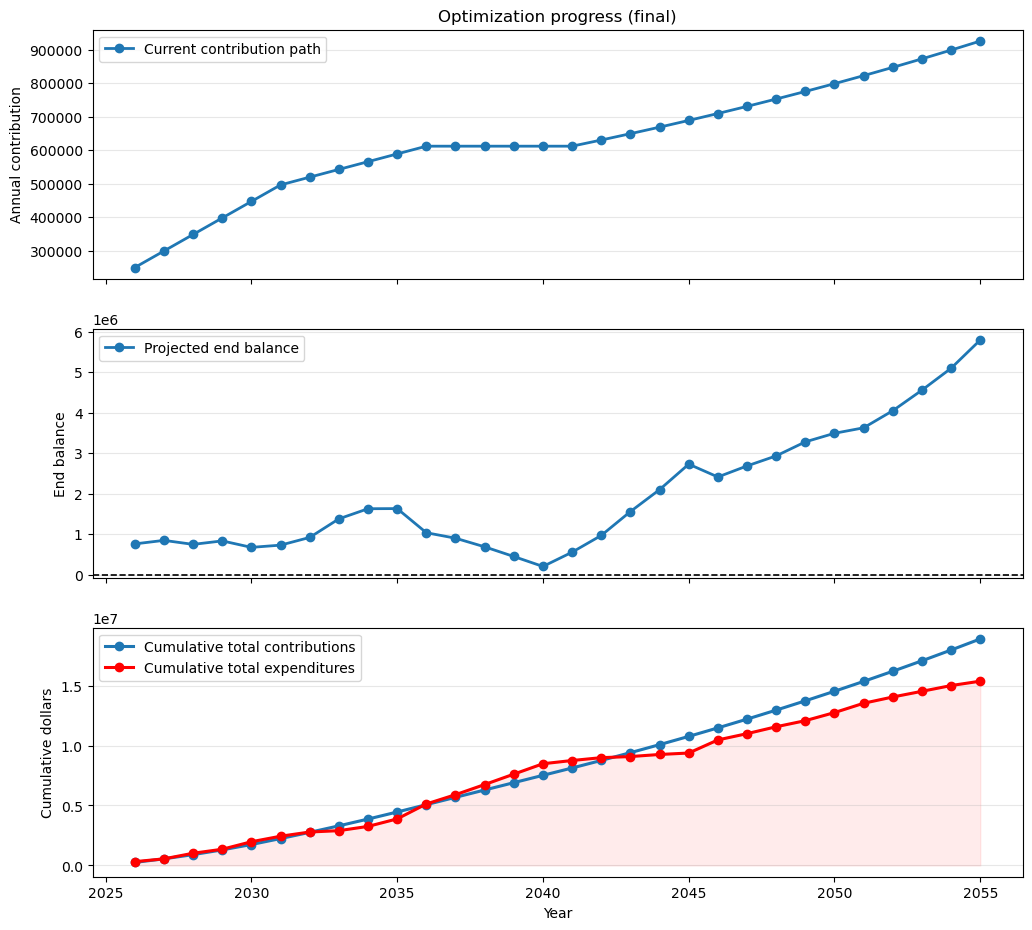

Min end balance: 200,000.00
Max end balance: 5,793,638.86
Total contributions: 18,903,687.10
Total expenditures: 15,377,725.51
Diagnostics:
{'success': True, 'message': 'Optimization terminated successfully', 'objective_value': 10713557.673845809, 'optimal_params': array([2.50000000e+05, 4.93145308e+04, 2.31189278e+04, 5.83911990e-02,
       5.00000000e+00, 5.00000000e+00, 5.00000000e+00]), 'years': array([2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
       2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
       2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055]), 'min_ending_balance': 200000.0, 'max_ending_balance': 5793638.86, 'total_contributions': 18903687.099699553, 'all_end_balances_nonnegative': True, 'iterations_plotted': 57}

Optimized assessments:


,year,contribution,special_assessment
0,2026,250000.000000,0.0
1,2027,299314.530786,0.0
2,2028,348629.061572,0.0
3,2029,397943.592358,0.0
4,2030,447258.123144,0.0
5,2031,496572.653929,0.0
6,2032,519691.581730,0.0
7,2033,542810.509531,0.0
8,2034,565929.437332,0.0
9,2035,589048.365133,0.0



Optimized projection:


,year,begin_balance,contribution,special_assessment,expenditures,interest,end_balance
0,2026,800000.00,250000.00,0.0,313093.32,20367.17,757273.85
1,2027,757273.85,299314.53,0.0,233109.89,20796.26,844274.75
2,2028,844274.75,348629.06,0.0,468771.86,21204.25,745336.20
3,2029,745336.20,397943.59,0.0,332699.03,20798.52,831379.28
4,2030,831379.28,447258.12,0.0,627675.52,20561.84,671523.73
5,2031,671523.73,496572.65,0.0,460389.79,18942.11,726648.70
6,2032,726648.70,519691.58,0.0,351127.95,21794.50,917006.83
7,2033,917006.83,542810.51,0.0,113410.15,29410.40,1375817.59
8,2034,1375817.59,565929.44,0.0,354705.65,38804.50,1625845.88
9,2035,1625845.88,589048.37,0.0,628147.58,42582.56,1629329.22



All annual ending balances are nonnegative.


In [80]:
# RUN OPTIMIZER

optimized_assessments, optimized_projection, diagnostics = optimize_reserve_schedule(
    contribution_fn=contribution_fn,
    objective_fn=objective_fn,
    initial_params=initial_params,
    bounds=bounds,
    expenditures_by_year_detail=expenditures_by_year_detail,
    assumptions=assumptions,
    assessment_contributions=assessment_contributions,
    start_year=START_YEAR,
    projection_years=PROJECTION_YEARS,
    min_balance=MIN_BALANCE,
    special_mode=special_mode,
    special_vector=special_vector,
    special_dict=special_dict,
    special_func=special_func,
    transform_fn=transform_fn,
    objective_weights=objective_weights,
    extra_penalty_fn=extra_penalty_fn,
    method="SLSQP",
    options={"maxiter": 2000, "ftol": 1e-9, "disp": False},
    plot_progress=PLOT_PROGRESS,
    plot_every=PLOT_EVERY,
)

print("Diagnostics:")
print(diagnostics)

print("\nOptimized assessments:")
display(optimized_assessments.head(30))

print("\nOptimized projection:")
display(optimized_projection.head(30))

if (optimized_projection["end_balance"] < 0).any():
    print("\nWarning: at least one year ended below zero.")
else:
    print("\nAll annual ending balances are nonnegative.")

In [79]:
print(optimized_projection['end_balance'])
print(optimized_projection['end_balance'].to_numpy()/fb_end.drop(fb_end.index[-1]).to_numpy())

0      757273.85
1      844274.75
2      745336.20
3      831379.28
4      671523.73
5      726648.70
6      917006.83
7     1375817.59
8     1625845.88
9     1629329.22
10    1033176.35
11     897857.39
12     685009.47
13     445976.19
14     200000.00
15     552371.42
16     966036.85
17    1555721.46
18    2097483.47
19    2726647.86
20    2410038.79
21    2682998.17
22    2931394.92
23    3277506.41
24    3489393.49
25    3624621.80
26    4046923.22
27    4554471.22
28    5095691.79
29    5793638.86
Name: end_balance, dtype: float64
[0.21335048 0.2230897  0.19622764 0.21008789 0.1754099  0.18742952
 0.22642706 0.30698431 0.34633963 0.35065237 0.25943778 0.23689974
 0.19396019 0.13682931 0.06682208 0.16530959 0.25759552 0.35889615
 0.43062171 0.49694337 0.4684483  0.49786905 0.52297475 0.55400524
 0.57310158 0.58569348 0.61489656 0.64535831 0.67363903 0.70426695]


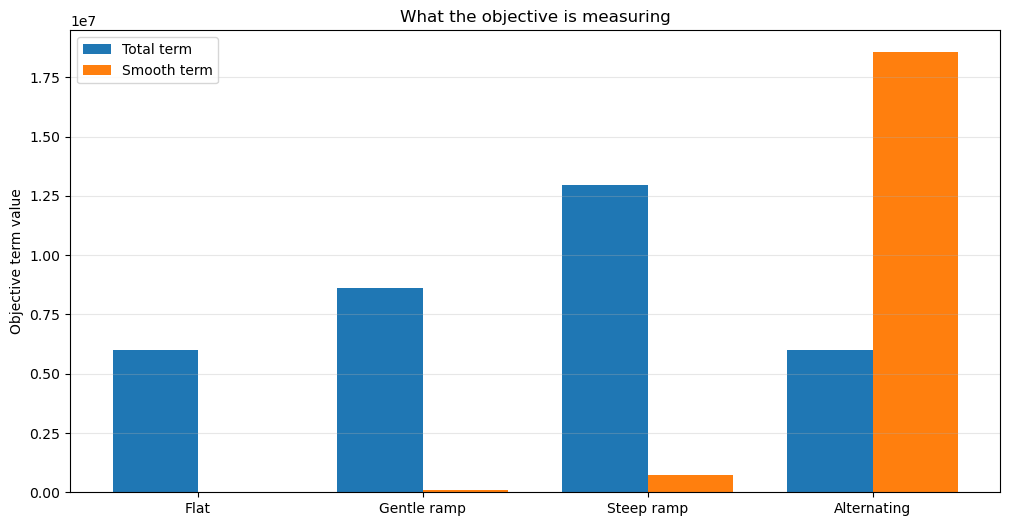

In [67]:
import numpy as np
import matplotlib.pyplot as plt

years = make_years(START_YEAR, PROJECTION_YEARS)
n = len(years)
k = np.arange(n)

base = 200000.0

candidate_paths = {
    "Flat": np.full(n, base),
    "Gentle ramp": base * (1 + 0.03 * k),
    "Steep ramp": base * (1 + 0.08 * k),
    "Alternating": base + 40000 * ((-1) ** k),
}

def term_values(contrib, total_weight=1.0, smooth_weight=1e-4):
    total_term = total_weight * np.sum(contrib)
    smooth_term = smooth_weight * np.sum(np.diff(contrib) ** 2)
    return total_term, smooth_term

total_vals = []
smooth_vals = []
labels = []

for name, contrib in candidate_paths.items():
    t, s = term_values(contrib, total_weight=1.0, smooth_weight=1e-4)
    labels.append(name)
    total_vals.append(t)
    smooth_vals.append(s)

x = np.arange(len(labels))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, total_vals, width, label="Total term")
plt.bar(x + width/2, smooth_vals, width, label="Smooth term")

plt.xticks(x, labels)
plt.ylabel("Objective term value")
plt.title("What the objective is measuring")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()